In [9]:
import pandas as pd

In [10]:
df_jan = pd.read_parquet('../data/url_jan.parquet')
df_feb = pd.read_parquet('../data/url_feb.parquet')
df = pd.concat([df_jan, df_feb], ignore_index=True)

In [11]:
df.head()

,hvfhs_license_num,dispatching_base_num,originating_base_num,request_datetime,on_scene_datetime,pickup_datetime,dropoff_datetime,PULocationID,DOLocationID,trip_miles,...,sales_tax,congestion_surcharge,airport_fee,tips,driver_pay,shared_request_flag,shared_match_flag,access_a_ride_flag,wav_request_flag,wav_match_flag
0,HV0003,B03404,B03404,2023-01-01 00:18:06,2023-01-01 00:19:24,2023-01-01 00:19:38,2023-01-01 00:48:07,48,68,0.94,...,2.30,2.75,0.0,5.22,27.83,N,N,,N,N
1,HV0003,B03404,B03404,2023-01-01 00:48:42,2023-01-01 00:56:20,2023-01-01 00:58:39,2023-01-01 01:33:08,246,163,2.78,...,5.34,2.75,0.0,0.00,50.15,N,N,,N,N
2,HV0003,B03404,B03404,2023-01-01 00:15:35,2023-01-01 00:20:14,2023-01-01 00:20:27,2023-01-01 00:37:54,9,129,8.81,...,2.16,0.00,0.0,0.00,20.22,N,N,,N,N
3,HV0003,B03404,B03404,2023-01-01 00:35:24,2023-01-01 00:39:30,2023-01-01 00:41:05,2023-01-01 00:48:16,129,129,0.67,...,1.22,0.00,0.0,0.00,7.90,N,N,,N,N
4,HV0003,B03404,B03404,2023-01-01 00:43:15,2023-01-01 00:51:10,2023-01-01 00:52:47,2023-01-01 01:04:51,129,92,4.38,...,1.82,0.00,0.0,0.00,16.48,N,N,,N,N


In [12]:
# Download taxi zone lookup (zone IDs → neighborhood names)
zones = pd.read_csv("../data/taxi_zone_lookup.csv")

In [13]:
zones.head()

,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone


In [14]:
df['request_datetime'] = pd.to_datetime(df['request_datetime'])
df['hour'] = df['request_datetime'].dt.hour
df['day_of_week'] = df['request_datetime'].dt.dayofweek
df['weekend'] = df['day_of_week'].isin([5, 6])
df['date'] =   df['request_datetime'].dt.date
df['day_of_week'] = pd.Categorical(df['request_datetime'].dt.day_name(), categories=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'], ordered=True)


In [15]:
df.dtypes

hvfhs_license_num               object
dispatching_base_num            object
originating_base_num            object
request_datetime        datetime64[us]
on_scene_datetime       datetime64[us]
pickup_datetime         datetime64[us]
dropoff_datetime        datetime64[us]
PULocationID                     int64
DOLocationID                     int64
trip_miles                     float64
trip_time                        int64
base_passenger_fare            float64
tolls                          float64
bcf                            float64
sales_tax                      float64
congestion_surcharge           float64
airport_fee                    float64
tips                           float64
driver_pay                     float64
shared_request_flag             object
shared_match_flag               object
access_a_ride_flag              object
wav_request_flag                object
wav_match_flag                  object
hour                             int32
day_of_week              

In [8]:
df.isnull().sum()

hvfhs_license_num             0
dispatching_base_num          0
originating_base_num    9565533
request_datetime              0
on_scene_datetime       9565533
pickup_datetime               0
dropoff_datetime              0
PULocationID                  0
DOLocationID                  0
trip_miles                    0
trip_time                     0
base_passenger_fare           0
tolls                         0
bcf                           0
sales_tax                     0
congestion_surcharge          0
airport_fee                   0
tips                          0
driver_pay                    0
shared_request_flag           0
shared_match_flag             0
access_a_ride_flag            0
wav_request_flag              0
wav_match_flag                0
hour                          0
day_of_week                   0
weekend                       0
date                          0
dtype: int64

In [16]:
df = df.merge(zones, left_on='PULocationID', right_on='LocationID', how='left')

In [31]:
df.head()

,hvfhs_license_num,dispatching_base_num,originating_base_num,request_datetime,on_scene_datetime,pickup_datetime,dropoff_datetime,PULocationID,DOLocationID,trip_miles,...,wav_request_flag,wav_match_flag,LocationID,Borough,Zone,service_zone,hour,day_of_week,weekend,date
0,HV0003,B03404,B03404,2023-01-01 00:18:06,2023-01-01 00:19:24,2023-01-01 00:19:38,2023-01-01 00:48:07,48,68,0.94,...,N,N,48,Manhattan,Clinton East,Yellow Zone,0,6,True,2023-01-01
1,HV0003,B03404,B03404,2023-01-01 00:48:42,2023-01-01 00:56:20,2023-01-01 00:58:39,2023-01-01 01:33:08,246,163,2.78,...,N,N,246,Manhattan,West Chelsea/Hudson Yards,Yellow Zone,0,6,True,2023-01-01
2,HV0003,B03404,B03404,2023-01-01 00:15:35,2023-01-01 00:20:14,2023-01-01 00:20:27,2023-01-01 00:37:54,9,129,8.81,...,N,N,9,Queens,Auburndale,Boro Zone,0,6,True,2023-01-01
3,HV0003,B03404,B03404,2023-01-01 00:35:24,2023-01-01 00:39:30,2023-01-01 00:41:05,2023-01-01 00:48:16,129,129,0.67,...,N,N,129,Queens,Jackson Heights,Boro Zone,0,6,True,2023-01-01
4,HV0003,B03404,B03404,2023-01-01 00:43:15,2023-01-01 00:51:10,2023-01-01 00:52:47,2023-01-01 01:04:51,129,92,4.38,...,N,N,129,Queens,Jackson Heights,Boro Zone,0,6,True,2023-01-01


In [17]:
daily_demand = df.groupby('date').size()
hourly_demand = df.groupby('hour').size()
weekday_demand = df.groupby('day_of_week').size().sort_index()
monthly_demand = df.groupby(df['request_datetime'].dt.to_period('M')).size()

/var/folders/v6/dd14sxks18sgdj6hgnqldnw80000gn/T/ipykernel_80699/698541940.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  weekday_demand = df.groupby('day_of_week').size().sort_index()


<Axes: title={'center': 'Weekly Ride Requests'}, xlabel='day_of_week'>

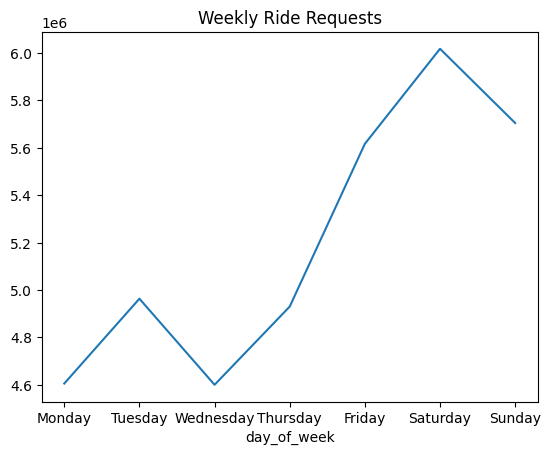

In [18]:
weekday_demand.plot(kind='line', title='Weekly Ride Requests')

<Axes: title={'center': 'Hourly Ride Requests'}, xlabel='hour'>

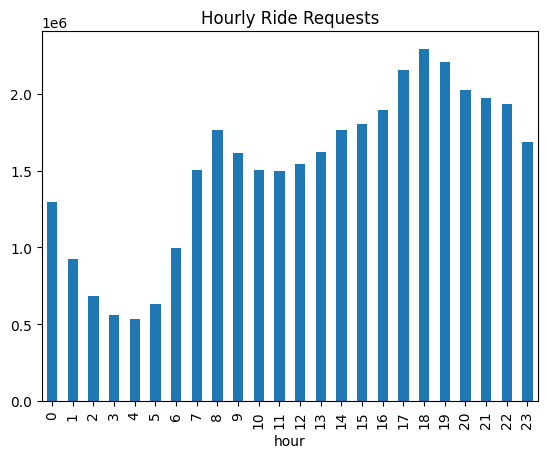

In [19]:
hourly_demand.plot(kind='bar', title='Hourly Ride Requests')

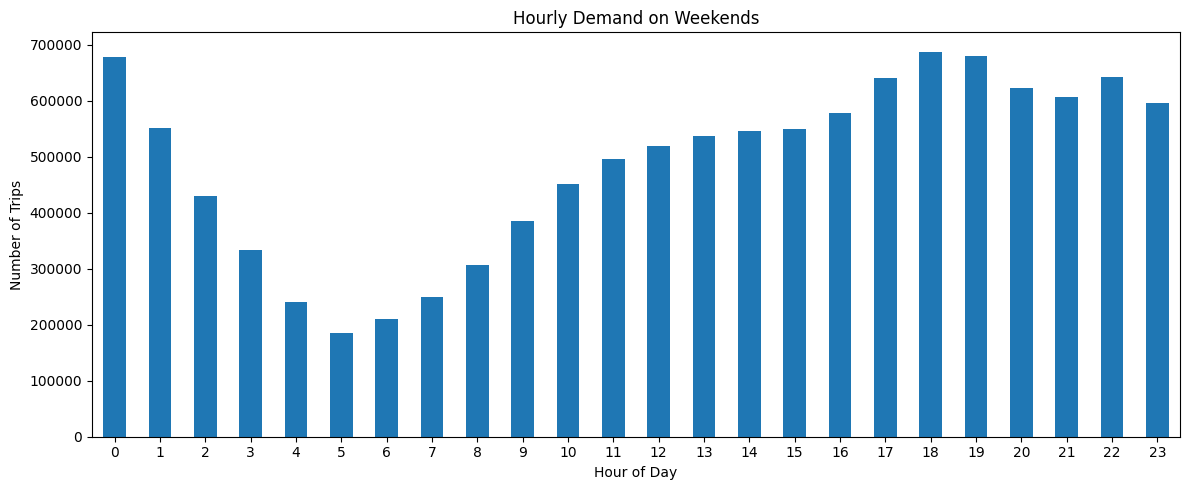

In [20]:
# Hourly demand on weekends only
import matplotlib.pyplot as plt

weekend_hourly_demand = df[df['weekend'] == True].groupby('hour').size()
weekend_hourly_demand.plot(kind='bar', figsize=(12, 5), title='Hourly Demand on Weekends')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Trips')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

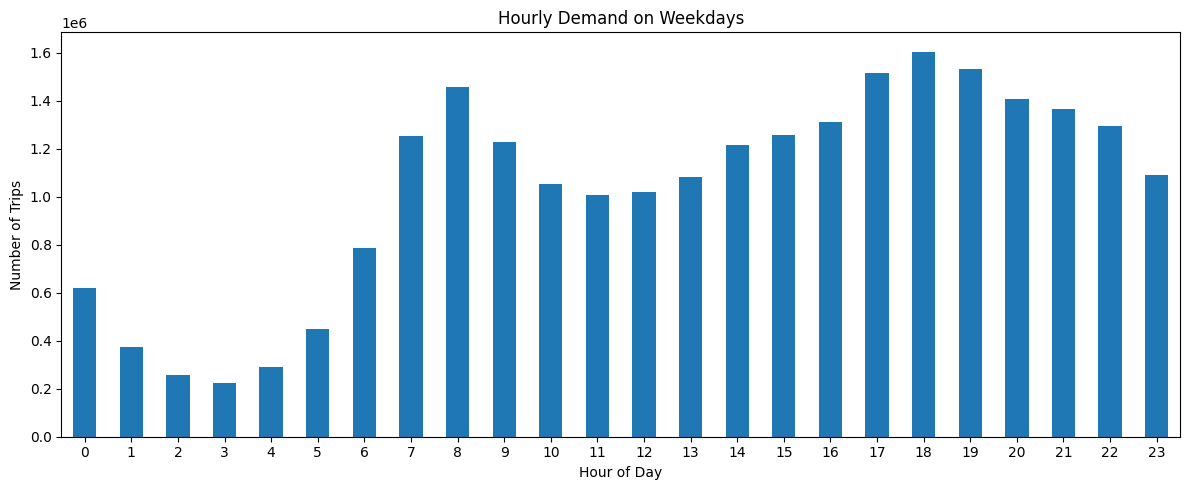

In [21]:
weekday_hourly_demand = df[df['weekend'] == False].groupby('hour').size()
weekday_hourly_demand.plot(kind='bar', figsize=(12, 5), title='Hourly Demand on Weekdays')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Trips')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

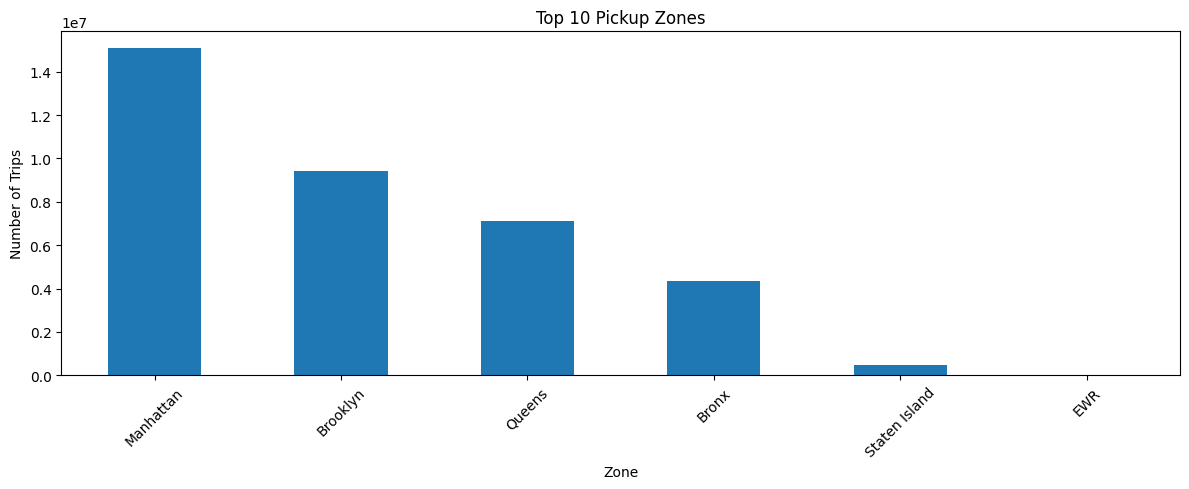

In [22]:
zone_demand = df.groupby('Borough').size().sort_values(ascending=False)
zone_demand.plot(kind='bar', figsize=(12, 5), title='Top 10 Pickup Zones')
plt.xlabel('Zone')
plt.ylabel('Number of Trips')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/var/folders/v6/dd14sxks18sgdj6hgnqldnw80000gn/T/ipykernel_80699/1548074672.py:3: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df.monthly_demand = df.groupby('month').size()


<Axes: title={'center': 'Monthly Ride Requests'}, xlabel='month'>

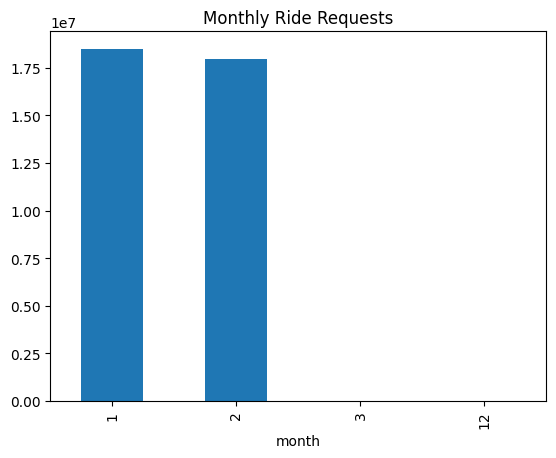

In [23]:
#What is the overall distribution of trip demand across the 2 months?
df['month'] = df['request_datetime'].dt.month
df.monthly_demand = df.groupby('month').size()
df.monthly_demand.plot(kind='bar', title='Monthly Ride Requests')

In [24]:
daily_demand.describe()

count        61.000000
mean     597377.081967
std      141943.088065
min           3.000000
25%      544048.000000
50%      611839.000000
75%      674133.000000
max      811400.000000
dtype: float64

In [25]:
daily_demand_by_month = df.groupby(['month', 'date']).size()

print(df[df['month']==1].groupby('date').size().describe())  # Jan stats
print(df[df['month']==2].groupby('date').size().describe())  # Feb stats

count        31.000000
mean     596103.483871
std       88384.161561
min      407507.000000
25%      527555.000000
50%      609590.000000
75%      661950.500000
max      754464.000000
dtype: float64
count        28.000000
mean     641417.250000
std       87721.719042
min      499328.000000
25%      582963.000000
50%      619977.500000
75%      712406.000000
max      811400.000000
dtype: float64


In [26]:
#df['trip_duration'] = (df['dropoff_datetime'] - df['pickup_datetime']).dt.total_seconds() / 60  # duration in minutes
#df['fare_amount'] = df['total_amount'] - df['tip_amount']  # fare without tip
df.head(1)  # convert seconds to minutes

,hvfhs_license_num,dispatching_base_num,originating_base_num,request_datetime,on_scene_datetime,pickup_datetime,dropoff_datetime,PULocationID,DOLocationID,trip_miles,...,wav_match_flag,hour,day_of_week,weekend,date,LocationID,Borough,Zone,service_zone,month
0,HV0003,B03404,B03404,2023-01-01 00:18:06,2023-01-01 00:19:24,2023-01-01 00:19:38,2023-01-01 00:48:07,48,68,0.94,...,N,0,Sunday,True,2023-01-01,48,Manhattan,Clinton East,Yellow Zone,1


<Axes: title={'center': 'Distribution of Trip Durations'}, ylabel='Frequency'>

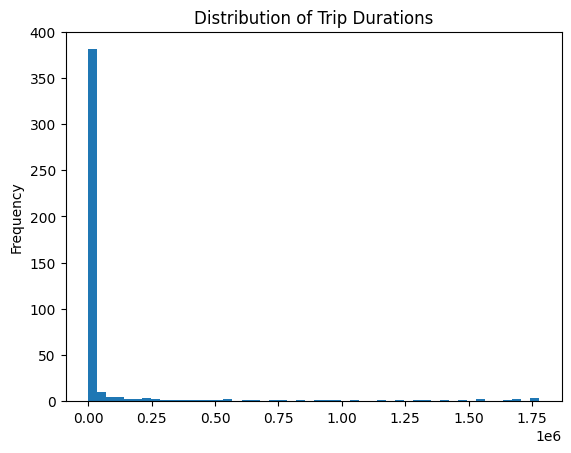

In [27]:
df['trip_duration'] = df['trip_time'] // 60  # convert seconds to minutes
trip_time_distribution = df.groupby('trip_duration').size()
trip_time_distribution.plot(kind='hist', bins=50, title='Distribution of Trip Durations')

<Axes: title={'center': 'Distribution of Trip Distances'}, ylabel='Frequency'>

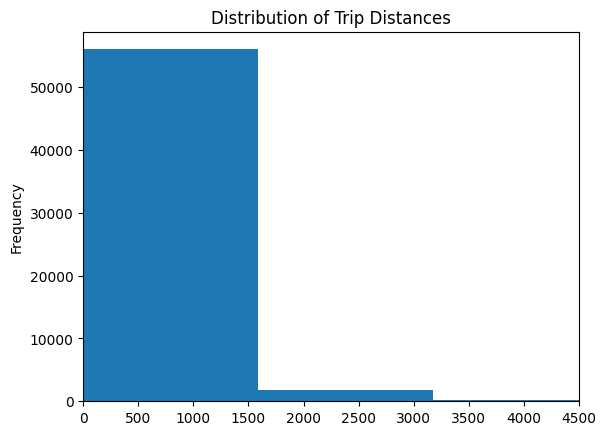

In [28]:
trip_distance_distribution = df.groupby('trip_miles').size()
trip_distance_distribution.plot(kind='hist', bins=50, title='Distribution of Trip Distances',xlim=(0, 4500))

In [29]:
df['trip_miles'].quantile([0.95, 0.99, 0.999])

0.950    15.93
0.990    25.80
0.999    50.65
Name: trip_miles, dtype: float64

In [30]:
df['trip_duration'].quantile([0.95, 0.99, 0.999])

0.950    42.0
0.990    61.0
0.999    92.0
Name: trip_duration, dtype: float64

In [31]:
df_clean = df[(df['trip_miles'] < 50)]

In [32]:
df_clean['trip_duration'].quantile([0.95, 0.99, 0.999])

0.950    42.0
0.990    60.0
0.999    86.0
Name: trip_duration, dtype: float64

<Axes: ylabel='Frequency'>

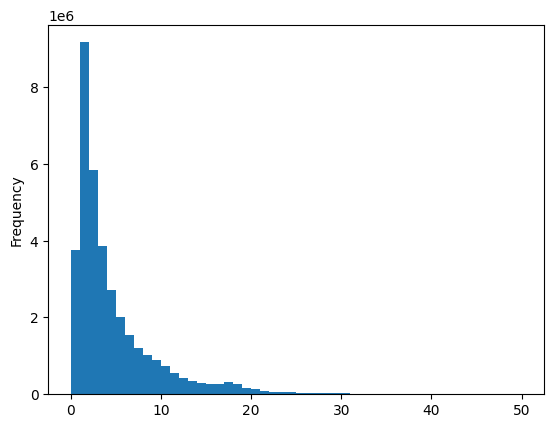

In [33]:
df_clean['trip_miles'].plot(kind='hist', bins=50)

In [34]:
df_clean = df_clean[(df_clean['trip_duration'] <= 180)]

In [35]:
df_clean['trip_duration'].quantile([0.95, 0.99, 0.999])

0.950    42.0
0.990    60.0
0.999    86.0
Name: trip_duration, dtype: float64

<Axes: ylabel='Frequency'>

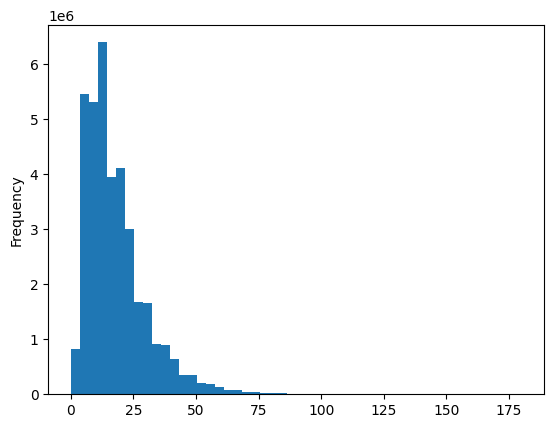

In [36]:
df_clean['trip_duration'].plot(kind='hist', bins=50)

<Axes: title={'center': 'Distribution of Base Passenger Fare'}, ylabel='Frequency'>

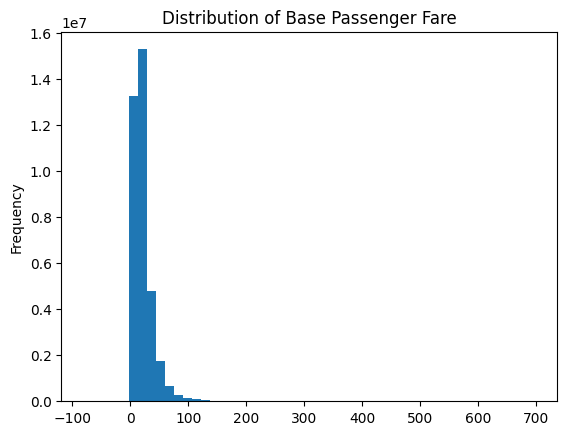

In [37]:
df_clean.base_passenger_fare.plot(kind='hist', bins=50, title='Distribution of Base Passenger Fare')

In [38]:
df_clean.base_passenger_fare.quantile([0.95, 0.99, 0.999])

0.950     53.68
0.990     88.06
0.999    147.57
Name: base_passenger_fare, dtype: float64

In [39]:
df_clean = df_clean[(df_clean['base_passenger_fare'] < 150) & (df_clean['base_passenger_fare'] > 0)]

<Axes: title={'center': 'Distribution of Base Passenger Fare (Cleaned)'}, ylabel='Frequency'>

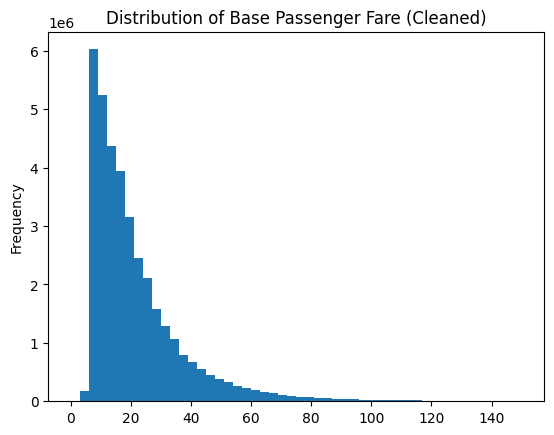

In [40]:
df_clean['base_passenger_fare'].plot(kind='hist', bins=50, title='Distribution of Base Passenger Fare (Cleaned)')

In [41]:
df_clean.head(1)

,hvfhs_license_num,dispatching_base_num,originating_base_num,request_datetime,on_scene_datetime,pickup_datetime,dropoff_datetime,PULocationID,DOLocationID,trip_miles,...,hour,day_of_week,weekend,date,LocationID,Borough,Zone,service_zone,month,trip_duration
0,HV0003,B03404,B03404,2023-01-01 00:18:06,2023-01-01 00:19:24,2023-01-01 00:19:38,2023-01-01 00:48:07,48,68,0.94,...,0,Sunday,True,2023-01-01,48,Manhattan,Clinton East,Yellow Zone,1,28


In [42]:
import seaborn as sns

In [46]:
sns.pairplot(df_clean[['day_of_week', 'trip_miles', 'trip_duration', 'base_passenger_fare', 'Zone']], hue='Zone')

: 